<a href="https://colab.research.google.com/github/GuilhermeMBertolo/CIC_IDS2017/blob/main/CIC_IDS_2017_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CIC-IDS-2017 | MLP

In [ ]:
# =====================================================
# 1. Ambiente e configuracao experimental
# =====================================================

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Sequential

warnings.filterwarnings('ignore')

SEED = 314159
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

PASTA = '/content/drive/MyDrive/CIC-IDS-2017/'
ARQUIVOS = [
    'Monday-WorkingHours.pcap_ISCX.csv',
    'Tuesday-WorkingHours.pcap_ISCX.csv',
    'Wednesday-workingHours.pcap_ISCX.csv',
    'Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv',
    'Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv',
    'Friday-WorkingHours-Morning.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv',
    'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
]

NOMES_CLASSES_BASE = [
    'BENIGN', 'DoS', 'DDoS', 'Brute Force',
    'Web Attack', 'Reconnaissance', 'Bot', 'Raros',
]
NOMES_CLASSES = NOMES_CLASSES_BASE.copy()

EPOCHS = 250
BATCH_SIZE = 1024
PATIENCE_EARLY_STOPPING = 10
PATIENCE_REDUCE_LR = 5


In [ ]:
# =====================================================
# 2. Carga, limpeza e agrupamento das classes
# =====================================================

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Ambiente local detectado. Ajuste PASTA para a pasta dos CSVs.')


def carregar_e_preparar(pasta, arquivos):
    tabelas = []
    for arquivo in arquivos:
        dados = pd.read_csv(os.path.join(pasta, arquivo), low_memory=False)
        dados.columns = dados.columns.str.strip()
        tabelas.append(dados)

    df = pd.concat(tabelas, ignore_index=True)
    df['Label'] = df['Label'].replace({
        'Web Attack Ã¯Â¿Â½ Brute Force': 'Web Attack - Brute Force',
        'Web Attack Ã¯Â¿Â½ Sql Injection': 'Web Attack - Sql Injection',
        'Web Attack Ã¯Â¿Â½ XSS': 'Web Attack - XSS',
        'Web Attack � Brute Force': 'Web Attack - Brute Force',
        'Web Attack � Sql Injection': 'Web Attack - Sql Injection',
        'Web Attack � XSS': 'Web Attack - XSS',
    })

    antes = len(df)
    df = df.dropna()
    colunas_numericas = df.select_dtypes(include=np.number).columns
    df = df.loc[np.isfinite(df[colunas_numericas]).all(axis=1)]
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'Linhas removidas na limpeza: {antes - len(df):,}')

    grupos = {
        'BENIGN': 'BENIGN',
        'DoS Hulk': 'DoS', 'DoS GoldenEye': 'DoS',
        'DoS Slowhttptest': 'DoS', 'DoS slowloris': 'DoS',
        'DDoS': 'DDoS',
        'FTP-Patator': 'Brute Force', 'SSH-Patator': 'Brute Force',
        'Web Attack - Brute Force': 'Web Attack',
        'Web Attack - Sql Injection': 'Web Attack',
        'Web Attack - XSS': 'Web Attack',
        'PortScan': 'Reconnaissance', 'Bot': 'Bot',
        'Infiltration': 'Raros', 'Heartbleed': 'Raros',
    }

    df['Label_grupo'] = df['Label'].map(grupos)
    df = df.dropna(subset=['Label_grupo']).copy()

    # Mantem os nomes em ordem padrao, mas remove classes ausentes para garantir
    # rotulos continuos: 0, 1, 2, ...
    global NOMES_CLASSES
    NOMES_CLASSES = [classe for classe in NOMES_CLASSES_BASE if classe in df['Label_grupo'].unique()]
    codigos = {nome: indice for indice, nome in enumerate(NOMES_CLASSES)}

    df['Label_final'] = df['Label_grupo'].map(codigos).astype(int)

    X = df.drop(columns=['Label', 'Label_grupo', 'Label_final'])
    y = df['Label_final']
    print(f'Dataset final: {X.shape[0]:,} linhas e {X.shape[1]} atributos')
    display(df['Label_grupo'].value_counts().reindex(NOMES_CLASSES).to_frame('quantidade'))
    return X, y


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# =====================================================
# 3. Divisao estratificada: 80% treino, 10% validacao, 10% teste
# =====================================================

X, y = carregar_e_preparar(PASTA, ARQUIVOS)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED, shuffle=True,
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=SEED, shuffle=True,
)

resumo_divisao = pd.DataFrame({
    'Conjunto': ['Treino', 'Validacao', 'Teste'],
    'Linhas': [len(X_train), len(X_val), len(X_test)],
    'Percentual': [len(X_train) / len(X), len(X_val) / len(X), len(X_test) / len(X)],
})
resumo_divisao['Percentual'] = (resumo_divisao['Percentual'] * 100).round(2)
display(resumo_divisao)


Linhas removidas na limpeza: 309,945
Dataset final: 2,520,798 linhas e 78 atributos


,quantidade
Label_grupo,
BENIGN,2095057
DoS,193745
DDoS,128014
Brute Force,9150
Web Attack,2143
Reconnaissance,90694
Bot,1948
Raros,47


,Conjunto,Linhas,Percentual
0,Treino,2016638,80.0
1,Validacao,252080,10.0
2,Teste,252080,10.0


In [ ]:
# =====================================================
# 4. Selecao de atributos por importancia do XGBoost
# =====================================================

# Mantem a caracteristica do MLP original: selecao por importancia acumulada de 95%.
seletor_xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=len(NOMES_CLASSES),
    eval_metric='mlogloss',
    random_state=SEED,
    tree_method='hist',
    n_estimators=200,
    learning_rate=0.10,
    max_depth=6,
    n_jobs=-1,
)
seletor_xgb.fit(X_train, y_train)

importancias = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': seletor_xgb.feature_importances_,
}).sort_values('Importance', ascending=False)
importancias['Importance (%)'] = importancias['Importance'] / importancias['Importance'].sum() * 100
importancias['Importancia_acumulada'] = importancias['Importance (%)'].cumsum()

features_selecionadas = importancias.loc[
    importancias['Importancia_acumulada'] <= 95,
    'Feature',
].tolist()

if not features_selecionadas:
    features_selecionadas = [importancias.iloc[0]['Feature']]

print(f'Features selecionadas: {len(features_selecionadas)}')
display(importancias[['Feature', 'Importance (%)', 'Importancia_acumulada']].head(20))


Features selecionadas: 21


,Feature,Importance (%),Importancia_acumulada
13,Bwd Packet Length Std,21.341778,21.341778
74,Idle Mean,13.450536,34.792313
76,Idle Max,11.666036,46.458347
12,Bwd Packet Length Mean,6.102605,52.560951
30,Fwd PSH Flags,5.469468,58.030418
68,act_data_pkt_fwd,5.322802,63.353222
52,Average Packet Size,5.023347,68.376572
4,Total Length of Fwd Packets,4.457003,72.833572
14,Flow Bytes/s,3.172047,76.005623
35,Bwd Header Length,3.134871,79.140495


In [ ]:
# =====================================================
# 5. Normalizacao ajustada somente no treino
# =====================================================

scaler = StandardScaler()
X_train_z = scaler.fit_transform(X_train[features_selecionadas])
X_val_z = scaler.transform(X_val[features_selecionadas])
X_test_z = scaler.transform(X_test[features_selecionadas])

print(f'Formato do treino normalizado: {X_train_z.shape}')
print(f'Formato da validacao normalizada: {X_val_z.shape}')
print(f'Formato do teste normalizado: {X_test_z.shape}')


Formato do treino normalizado: (2016638, 21)
Formato da validacao normalizada: (252080, 21)
Formato do teste normalizado: (252080, 21)


In [ ]:
# =====================================================
# 6. Modelo MLP
# =====================================================

input_shape = X_train_z.shape[1]
num_classes = len(NOMES_CLASSES)

# Arquitetura principal mantida do notebook original: modelo maximal.
mlp_final = Sequential([
    Input(shape=(input_shape,)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(num_classes, activation='softmax'),
])

mlp_final.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
)

mlp_final.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 8)              │            72 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,888 (54.25 KB)

 Trainable params: 13,888 (54.25 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# =====================================================
# 7. Treinamento com validacao
# =====================================================

pesos = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train,
)
pesos_classes = dict(zip(np.unique(y_train), pesos))
print('Pesos das classes:', pesos_classes)

callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=PATIENCE_EARLY_STOPPING,
        restore_best_weights=True,
        verbose=1,
    ),
    ReduceLROnPlateau(
        monitor='val_accuracy',
        patience=PATIENCE_REDUCE_LR,
        factor=0.1,
        min_lr=1e-7,
        verbose=1,
    ),
]

history = mlp_final.fit(
    X_train_z,
    y_train,
    validation_data=(X_val_z, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=pesos_classes,
    callbacks=callbacks,
    verbose=1,
)


Pesos das classes: {np.int64(0): np.float64(0.15040154053142965), np.int64(1): np.float64(1.6263629383984102), np.int64(2): np.float64(2.4614518948159865), np.int64(3): np.float64(34.437124316939894), np.int64(4): np.float64(147.071032672112), np.int64(5): np.float64(3.4743263730962717), np.int64(6): np.float64(161.6932328415651), np.int64(7): np.float64(6633.6776315789475)}
Epoch 1/250
1970/1970 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.5688 - loss: 1.2559 - val_accuracy: 0.5737 - val_loss: 0.9856 - learning_rate: 0.0010
Epoch 2/250
1970/1970 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.6156 - loss: 0.4934 - val_accuracy: 0.7071 - val_loss: 0.7599 - learning_rate: 0.0010
Epoch 3/250
1970/1970 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.7670 - loss: 0.3497 - val_accuracy: 0.8720 - val_loss: 0.4985 - learning_rate: 0.0010
Epoch 4/250
1970/1970 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step - accuracy: 0.7312 - loss: 0.5742 - val_accuracy: 0.7239 - val_loss: 0.6729 - learning_rate: 0.001

In [ ]:
# =====================================================
# 8. Avaliacao no teste isolado
# =====================================================

test_loss, test_accuracy = mlp_final.evaluate(X_test_z, y_test, verbose=0)
y_pred_prob = mlp_final.predict(X_test_z, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)

metricas = pd.DataFrame({
    'Metrica': ['Loss', 'Accuracy', 'Precision weighted', 'Recall weighted', 'F1 weighted', 'F1 macro', 'Balanced accuracy'],
    'Valor': [
        test_loss,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred, average='weighted', zero_division=0),
        recall_score(y_test, y_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_pred, average='weighted', zero_division=0),
        f1_score(y_test, y_pred, average='macro', zero_division=0),
        balanced_accuracy_score(y_test, y_pred),
    ],
})
metricas['Valor (%)'] = metricas['Valor']
metricas.loc[metricas['Metrica'] != 'Loss', 'Valor (%)'] = (
    metricas.loc[metricas['Metrica'] != 'Loss', 'Valor'] * 100
)
metricas['Valor (%)'] = metricas['Valor (%)'].round(4)
display(metricas[['Metrica', 'Valor (%)']])

print(classification_report(
    y_test, y_pred, labels=range(len(NOMES_CLASSES)),
    target_names=NOMES_CLASSES, digits=4, zero_division=0,
))


,Metrica,Valor (%)
0,Loss,0.3942
1,Accuracy,89.4883
2,Precision weighted,95.9224
3,Recall weighted,89.4883
4,F1 weighted,92.1981
5,F1 macro,52.1855
6,Balanced accuracy,89.6305


                precision    recall  f1-score   support

        BENIGN     0.9895    0.8833    0.9334    209506
           DoS     0.8599    0.9050    0.8819     19374
          DDoS     0.8861    0.9895    0.9349     12802
   Brute Force     0.2995    0.9749    0.4583       915
    Web Attack     0.0581    0.9209    0.1093       215
Reconnaissance     0.6849    0.9968    0.8119      9070
           Bot     0.0188    1.0000    0.0370       194
         Raros     0.0041    0.5000    0.0082         4

      accuracy                         0.8949    252080
     macro avg     0.4751    0.8963    0.5219    252080
  weighted avg     0.9592    0.8949    0.9220    252080



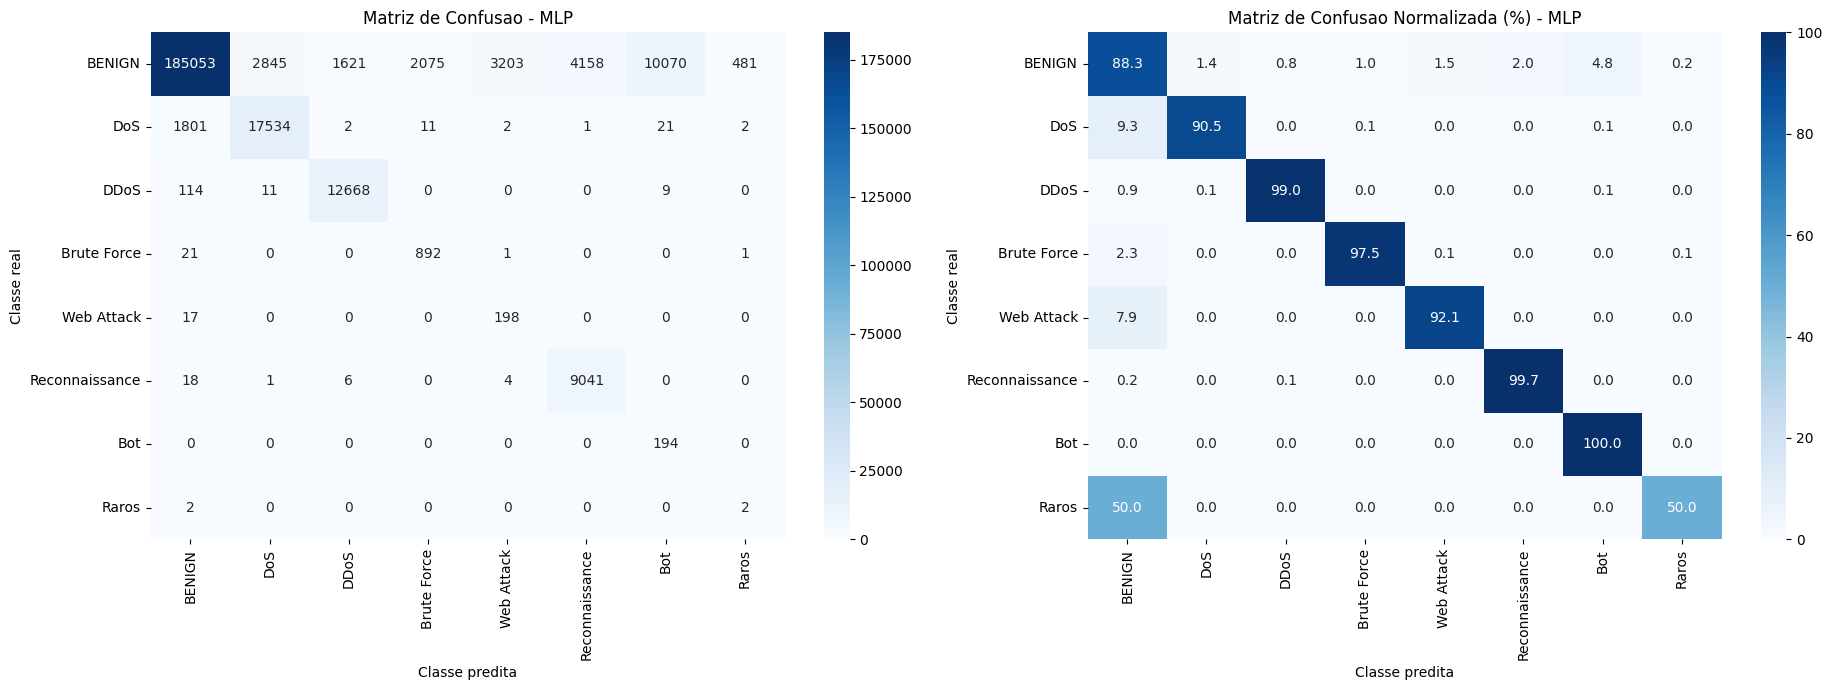

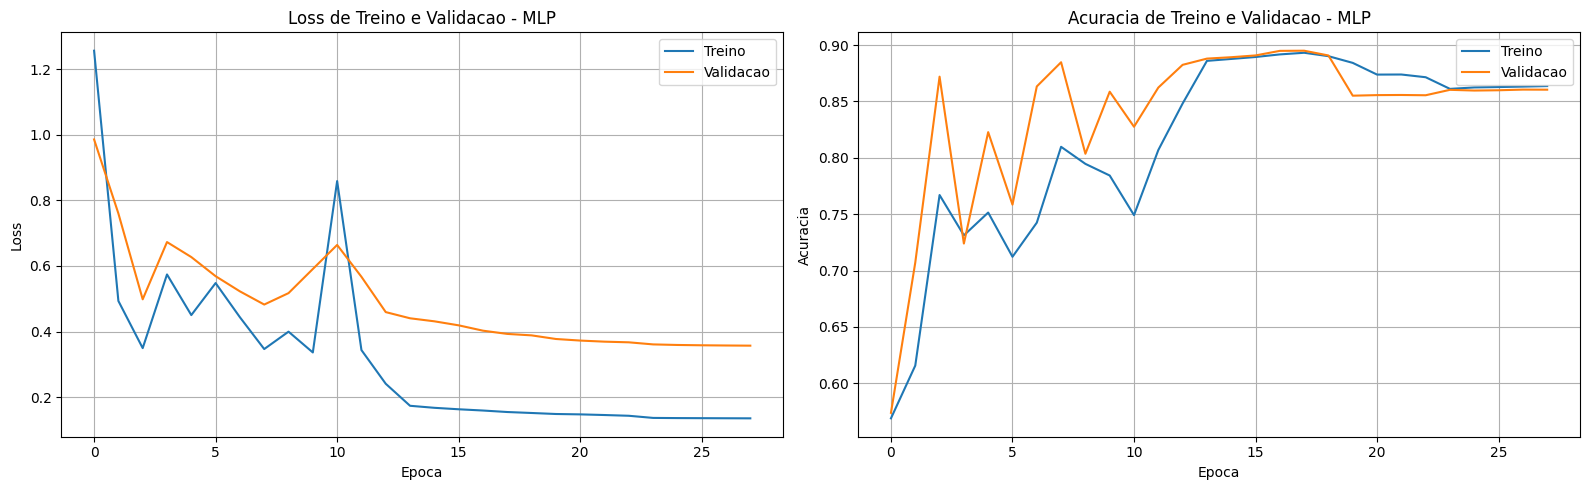

In [ ]:
# =====================================================
# 9. Analise visual dos resultados
# =====================================================

cm = confusion_matrix(y_test, y_pred, labels=range(len(NOMES_CLASSES)))
cm_percent = np.nan_to_num(cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100)

fig, axes = plt.subplots(1, 2, figsize=(19, 7))
sns.heatmap(pd.DataFrame(cm, index=NOMES_CLASSES, columns=NOMES_CLASSES), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set(title='Matriz de Confusao - MLP', xlabel='Classe predita', ylabel='Classe real')

sns.heatmap(pd.DataFrame(cm_percent, index=NOMES_CLASSES, columns=NOMES_CLASSES), annot=True, fmt='.1f', cmap='Blues', ax=axes[1])
axes[1].set(title='Matriz de Confusao Normalizada (%) - MLP', xlabel='Classe predita', ylabel='Classe real')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(history.history['loss'], label='Treino')
axes[0].plot(history.history['val_loss'], label='Validacao')
axes[0].set(title='Loss de Treino e Validacao - MLP', xlabel='Epoca', ylabel='Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history.history['accuracy'], label='Treino')
axes[1].plot(history.history['val_accuracy'], label='Validacao')
axes[1].set(title='Acuracia de Treino e Validacao - MLP', xlabel='Epoca', ylabel='Acuracia')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# =====================================================
# 10. Quantidade de acertos e desvio padrao
# =====================================================

# Quantidade absoluta de acertos/erros na avaliacao principal da etapa 8.
y_test_array = y_test.to_numpy() if hasattr(y_test, 'to_numpy') else np.asarray(y_test)

quantidade_acertos = int((y_test_array == y_pred).sum())
quantidade_erros = int((y_test_array != y_pred).sum())
total_avaliado = len(y_test_array)

resumo_acertos = pd.DataFrame({
    'Indicador': ['Acertos', 'Erros', 'Total avaliado', 'Taxa de acerto (%)'],
    'Valor': [
        quantidade_acertos,
        quantidade_erros,
        total_avaliado,
        round(quantidade_acertos / total_avaliado * 100, 2),
    ],
})
display(resumo_acertos)

# Estimativa de media e desvio padrao por repeticoes no teste isolado.
# O modelo nao e retreinado; apenas avaliamos amostras estratificadas diferentes.
N_REPETICOES_DESVIO = 5
MAX_TESTE_DESVIO_MLP = 10_000


def amostra_estratificada_array(X_array, y_array, max_linhas, seed):
    y_array = np.asarray(y_array)
    if max_linhas is None or len(y_array) <= max_linhas:
        return X_array, y_array

    indices = np.arange(len(y_array))
    indices_amostra, _ = train_test_split(
        indices,
        train_size=max_linhas,
        stratify=y_array,
        random_state=seed,
        shuffle=True,
    )
    return X_array[indices_amostra], y_array[indices_amostra]


resultados_repetidos = []

for repeticao in range(N_REPETICOES_DESVIO):
    X_rep, y_rep = amostra_estratificada_array(
        X_test_z,
        y_test_array,
        MAX_TESTE_DESVIO_MLP,
        SEED + 100 + repeticao,
    )
    pred_rep = np.argmax(mlp_final.predict(X_rep, verbose=0), axis=1)
    resultados_repetidos.append({
        'Repeticao': repeticao + 1,
        'Total avaliado': len(y_rep),
        'Acertos': int((y_rep == pred_rep).sum()),
        'Erros': int((y_rep != pred_rep).sum()),
        'Accuracy': accuracy_score(y_rep, pred_rep),
        'Precision weighted': precision_score(y_rep, pred_rep, average='weighted', zero_division=0),
        'Recall weighted': recall_score(y_rep, pred_rep, average='weighted', zero_division=0),
        'F1 weighted': f1_score(y_rep, pred_rep, average='weighted', zero_division=0),
        'F1 macro': f1_score(y_rep, pred_rep, average='macro', zero_division=0),
        'Balanced accuracy': balanced_accuracy_score(y_rep, pred_rep),
    })

resultados_repetidos = pd.DataFrame(resultados_repetidos)
display(resultados_repetidos)

resumo_desvio = resultados_repetidos.drop(columns=['Repeticao']).agg(['mean', 'std']).T
resumo_desvio.columns = ['Media', 'Desvio padrao']

for coluna in ['Media', 'Desvio padrao']:
    resumo_desvio[coluna] = resumo_desvio[coluna].round(4)

display(resumo_desvio)


,Indicador,Valor
0,Acertos,225582.00
1,Erros,26498.00
2,Total avaliado,252080.00
3,Taxa de acerto (%),89.49


,Repeticao,Total avaliado,Acertos,Erros,Accuracy,Precision weighted,Recall weighted,F1 weighted,F1 macro,Balanced accuracy
0,1,10000,8911,1089,0.8911,0.955219,0.8911,0.917915,0.517139,0.962606
1,2,10000,8916,1084,0.8916,0.959401,0.8916,0.920315,0.517357,0.930544
2,3,10000,8944,1056,0.8944,0.959191,0.8944,0.921626,0.519464,0.963934
3,4,10000,8977,1023,0.8977,0.960413,0.8977,0.924367,0.526574,0.951000
4,5,10000,8940,1060,0.8940,0.959085,0.8940,0.921394,0.518835,0.963528


,Media,Desvio padrao
Total avaliado,10000.0000,0.0000
Acertos,8937.6000,26.3306
Erros,1062.4000,26.3306
Accuracy,0.8938,0.0026
Precision weighted,0.9587,0.0020
Recall weighted,0.8938,0.0026
F1 weighted,0.9211,0.0023
F1 macro,0.5199,0.0039
Balanced accuracy,0.9543,0.0143
